# Yearly Sunspot Forecasting with Prophet

This notebook builds and evaluates Prophet models for yearly total sunspot observations from the World Data Center SILSO. It compares linear, flat, and logistic growth, several representations of the approximately 11-year solar cycle, and different changepoint settings.

The evaluation uses a chronological holdout period. MAE is the primary selection metric. MAPE excludes observations where the actual sunspot count is zero because percentage error is undefined at zero.

## 1. Setup

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score

warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

SOLAR_CYCLE_DAYS = 11 * 365.25
RANDOM_SEED = 42

c:\Abdullah Zahid\Programming\Github\Time-series-forecasting-for-Sunspots\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
def zero_safe_mape(actual, predicted):
    """Return MAPE over observations whose actual value is nonzero."""
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    mask = actual != 0
    return mean_absolute_percentage_error(actual[mask], predicted[mask]) * 100


def detect_time_unit(dates):
    """Infer the time unit and Prophet frequency from timestamp spacing."""
    ordered_dates = (
        pd.Series(pd.to_datetime(dates))
        .dropna()
        .drop_duplicates()
        .sort_values()
    )
    if len(ordered_dates) < 3:
        raise ValueError("At least three unique dates are required to infer frequency.")

    median_days = ordered_dates.diff().dropna().dt.total_seconds().median() / 86_400
    if 0.5 <= median_days <= 1.5:
        return "day", "D", median_days
    if 27 <= median_days <= 32:
        return "month", "MS", median_days
    if 360 <= median_days <= 370:
        return "year", "YS", median_days

    raise ValueError(f"Unsupported or irregular time spacing: {median_days:.2f} days")


def add_bounds(frame, cap):
    bounded = frame.copy()
    bounded["floor"] = 0.0
    bounded["cap"] = cap
    return bounded


def build_model(config, uncertainty_samples=0):
    kwargs = {
        "growth": config["growth"],
        "yearly_seasonality": False,
        "weekly_seasonality": False,
        "daily_seasonality": False,
        "seasonality_mode": "additive",
        "interval_width": 0.80,
        "uncertainty_samples": uncertainty_samples,
    }
    if config["growth"] != "flat":
        kwargs["n_changepoints"] = config["n_changepoints"]
        kwargs["changepoint_prior_scale"] = config["changepoint_prior_scale"]

    model = Prophet(**kwargs)
    model.add_seasonality(
        name="solar_cycle",
        period=config["period_days"],
        fourier_order=config["fourier_order"],
    )
    return model


def evaluate_config(train, test, config):
    cap = max(train["y"].max(), test["y"].max()) * 1.20
    train_input = add_bounds(train, cap) if config["growth"] == "logistic" else train.copy()
    model = build_model(config)
    model.fit(train_input, seed=RANDOM_SEED)

    prediction_input = test[["ds"]].copy()
    if config["growth"] == "logistic":
        prediction_input = add_bounds(prediction_input, cap)
    predicted = model.predict(prediction_input)["yhat"].clip(lower=0)

    return {
        "model": config["name"],
        "growth": config["growth"],
        "period_years": config["period_days"] / 365.25,
        "fourier_order": config["fourier_order"],
        "n_changepoints": config.get("n_changepoints", 0),
        "changepoint_prior_scale": config.get("changepoint_prior_scale", 0.0),
        "MAE": mean_absolute_error(test["y"], predicted),
        "MAPE_nonzero_pct": zero_safe_mape(test["y"], predicted),
        "R2": r2_score(test["y"], predicted),
    }


MODEL_CONFIGS = [
    {
        "name": "linear_10.5y_f5",
        "growth": "linear",
        "period_days": 10.5 * 365.25,
        "fourier_order": 5,
        "n_changepoints": 25,
        "changepoint_prior_scale": 0.05,
    },
    {
        "name": "linear_11y_f10",
        "growth": "linear",
        "period_days": 11 * 365.25,
        "fourier_order": 10,
        "n_changepoints": 50,
        "changepoint_prior_scale": 0.10,
    },
    {
        "name": "linear_11.5y_f15",
        "growth": "linear",
        "period_days": 11.5 * 365.25,
        "fourier_order": 15,
        "n_changepoints": 75,
        "changepoint_prior_scale": 0.20,
    },
    {
        "name": "flat_11y_f10",
        "growth": "flat",
        "period_days": 11 * 365.25,
        "fourier_order": 10,
    },
    {
        "name": "logistic_11y_f10",
        "growth": "logistic",
        "period_days": 11 * 365.25,
        "fourier_order": 10,
        "n_changepoints": 50,
        "changepoint_prior_scale": 0.10,
    },
]

## 2. Load and prepare the data

In [3]:
columns = ["decimal_year", "sunspots", "std_dev", "observations", "status"]
raw = pd.read_csv(RAW_DATA_DIR / "SN_y_tot_V2.0.csv", sep=";", header=None, names=columns)
raw["year"] = np.floor(raw["decimal_year"]).astype(int)
# Prophet and pandas cannot represent a nanosecond-resolution span longer than
# roughly 292 years. Starting in 1750 preserves more than 24 solar cycles while
# keeping the full modeling window within that supported range.
raw = raw.loc[raw["year"] >= 1750].copy()
raw["ds"] = pd.to_datetime(raw["year"].astype(str), format="%Y")
data = (
    raw.loc[raw["sunspots"] >= 0, ["ds", "sunspots"]]
    .rename(columns={"sunspots": "y"})
    .sort_values("ds")
    .drop_duplicates("ds")
    .reset_index(drop=True)
)
data["y"] = data["y"].astype(float)

In [4]:
time_unit, detected_frequency, median_spacing_days = detect_time_unit(data["ds"])

print(f"Rows: {len(data):,}")
print(f"Date range: {data['ds'].min().date()} to {data['ds'].max().date()}")
print(f"Missing values: {data.isna().sum().sum():,}")
print(f"Duplicate dates: {data['ds'].duplicated().sum():,}")
print(f"Detected time unit: {time_unit}")
print(f"Prophet frequency: {detected_frequency}")
print(f"Median timestamp spacing: {median_spacing_days:.2f} days")
data.head()

Rows: 272
Date range: 1750-01-01 to 2021-01-01
Missing values: 0
Duplicate dates: 0
Detected time unit: year
Prophet frequency: YS
Median timestamp spacing: 365.00 days


,ds,y
0,1750-01-01,139.000
1,1751-01-01,79.500
2,1752-01-01,79.700
3,1753-01-01,51.200
4,1754-01-01,20.300


In [5]:
data.to_csv(PROCESSED_DATA_DIR / "yearly_sunspots.csv", index=False)
data.describe(include="all")

,ds,y
count,272,272.000
mean,1885-07-01 23:49:24.705882624,81.307
min,1750-01-01 00:00:00,0.000
25%,1817-10-01 18:00:00,24.850
50%,1885-07-02 12:00:00,69.600
75%,1953-04-02 06:00:00,117.775
max,2021-01-01 00:00:00,269.300
std,NaN,63.261


## 3. Historical pattern

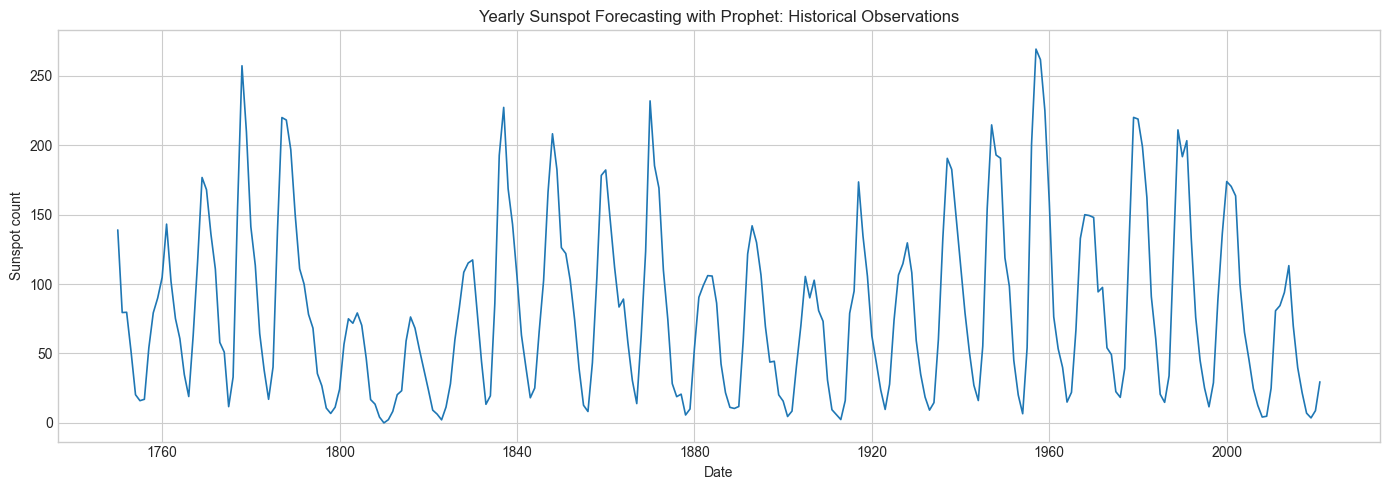

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(data["ds"], data["y"], color="#1f77b4", linewidth=1.2)
ax.set(title="Yearly Sunspot Forecasting with Prophet: Historical Observations", xlabel="Date", ylabel="Sunspot count")
plt.tight_layout()
plt.show()

## 4. Chronological validation

The final 22 years (two solar cycles) form the test set. Every candidate model is trained only on earlier observations, which prevents future values from influencing model selection.

In [7]:
train = data.iloc[:-22].copy()
test = data.iloc[-22:].copy()

In [8]:
print(f"Training rows: {len(train):,} ({train['ds'].min().date()} to {train['ds'].max().date()})")
print(f"Test rows: {len(test):,} ({test['ds'].min().date()} to {test['ds'].max().date()})")

Training rows: 250 (1750-01-01 to 1999-01-01)
Test rows: 22 (2000-01-01 to 2021-01-01)


## 5. Compare Prophet configurations

In [9]:
evaluation_rows = []
for config in MODEL_CONFIGS:
    print(f"Fitting {config['name']}...")
    evaluation_rows.append(evaluate_config(train, test, config))

results = (
    pd.DataFrame(evaluation_rows)
    .sort_values(["MAE", "MAPE_nonzero_pct"])
    .reset_index(drop=True)
)
results

18:05:35 - cmdstanpy - INFO - Chain [1] start processing


Fitting linear_10.5y_f5...


18:05:36 - cmdstanpy - INFO - Chain [1] done processing
18:05:36 - cmdstanpy - INFO - Chain [1] start processing
18:05:36 - cmdstanpy - INFO - Chain [1] done processing


Fitting linear_11y_f10...
Fitting linear_11.5y_f15...


18:05:36 - cmdstanpy - INFO - Chain [1] start processing
18:05:36 - cmdstanpy - INFO - Chain [1] done processing
18:05:36 - cmdstanpy - INFO - Chain [1] start processing
18:05:36 - cmdstanpy - INFO - Chain [1] done processing


Fitting flat_11y_f10...
Fitting logistic_11y_f10...


18:05:36 - cmdstanpy - INFO - Chain [1] start processing
18:05:36 - cmdstanpy - INFO - Chain [1] done processing


,model,growth,period_years,fourier_order,n_changepoints,changepoint_prior_scale,MAE,MAPE_nonzero_pct,R2
0,logistic_11y_f10,logistic,11.000,10,50,0.100,39.973,248.016,0.357
1,flat_11y_f10,flat,11.000,10,0,0.000,41.564,174.047,0.192
2,linear_10.5y_f5,linear,10.500,5,25,0.050,54.466,526.936,-0.431
3,linear_11y_f10,linear,11.000,10,50,0.100,54.962,372.628,-0.111
4,linear_11.5y_f15,linear,11.500,15,75,0.200,64.756,624.327,-0.903


In [10]:
best_name = results.loc[0, "model"]
best_config = next(config for config in MODEL_CONFIGS if config["name"] == best_name)
print(f"Selected model: {best_name}")
best_config

Selected model: logistic_11y_f10


{'name': 'logistic_11y_f10',
 'growth': 'logistic',
 'period_days': 4017.75,
 'fourier_order': 10,
 'n_changepoints': 50,
 'changepoint_prior_scale': 0.1}

## 6. Validate the selected model

In [11]:
validation_cap = max(train["y"].max(), test["y"].max()) * 1.20
validation_train = add_bounds(train, validation_cap) if best_config["growth"] == "logistic" else train.copy()
validation_model = build_model(best_config)
validation_model.fit(validation_train, seed=RANDOM_SEED)

validation_input = test[["ds"]].copy()
if best_config["growth"] == "logistic":
    validation_input = add_bounds(validation_input, validation_cap)

validation_forecast = validation_model.predict(validation_input)
validation_table = test.copy()
validation_table["predicted"] = validation_forecast["yhat"].clip(lower=0).to_numpy()
validation_table.head()

18:05:36 - cmdstanpy - INFO - Chain [1] start processing
18:05:37 - cmdstanpy - INFO - Chain [1] done processing


,ds,y,predicted
250,2000-01-01,173.900,77.826
251,2001-01-01,170.400,108.565
252,2002-01-01,163.600,134.572
253,2003-01-01,99.300,132.106
254,2004-01-01,65.300,109.601


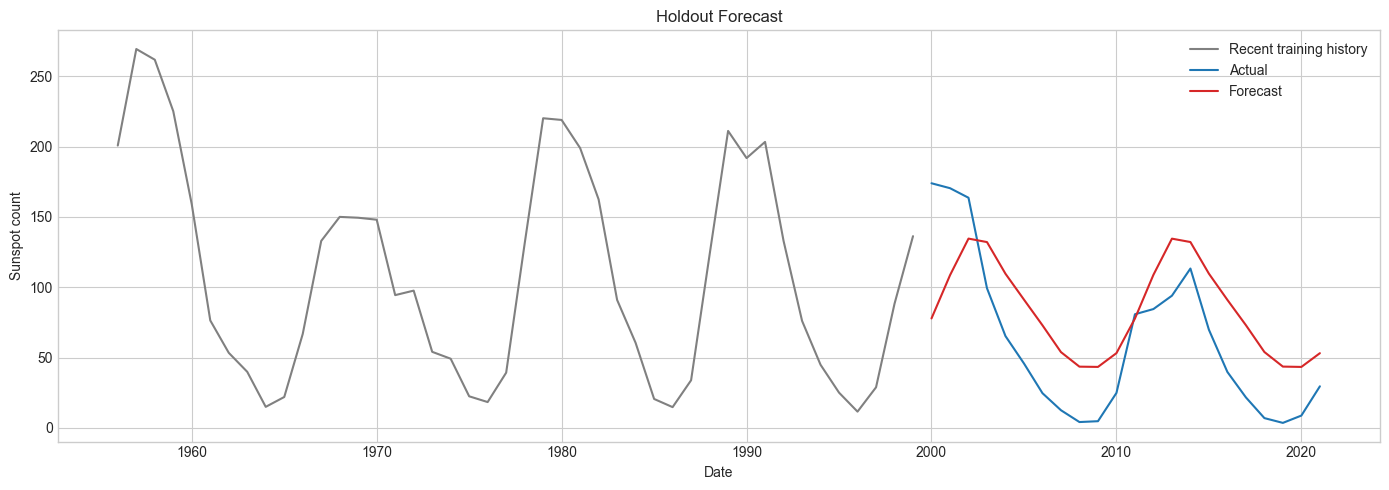

In [12]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train["ds"].tail(len(test) * 2), train["y"].tail(len(test) * 2), label="Recent training history", color="#808080")
ax.plot(test["ds"], test["y"], label="Actual", color="#1f77b4")
ax.plot(validation_table["ds"], validation_table["predicted"], label="Forecast", color="#d62728")
ax.set(title="Holdout Forecast", xlabel="Date", ylabel="Sunspot count")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Fit the selected model to the full history

In [13]:
final_cap = data["y"].max() * 1.20
final_training = add_bounds(data, final_cap) if best_config["growth"] == "logistic" else data.copy()
final_model = build_model(best_config, uncertainty_samples=200)
final_model.fit(final_training, seed=RANDOM_SEED)

future = final_model.make_future_dataframe(
    periods=20,
    freq=detected_frequency,
    include_history=False,
)
if best_config["growth"] == "logistic":
    future = add_bounds(future, final_cap)

forecast = final_model.predict(future)
forecast["yhat"] = forecast["yhat"].clip(lower=0)
forecast["yhat_lower"] = forecast["yhat_lower"].clip(lower=0)
forecast["yhat_upper"] = forecast["yhat_upper"].clip(lower=0)

18:05:37 - cmdstanpy - INFO - Chain [1] start processing
18:05:37 - cmdstanpy - INFO - Chain [1] done processing


## 8. Selected future horizons

In [14]:
last_observed = data["ds"].max()
horizon_dates = [last_observed + pd.DateOffset(years=years) for years in [1, 10, 20]]
forecast_table = forecast.loc[forecast["ds"].isin(horizon_dates), ["ds", "yhat", "yhat_lower", "yhat_upper"]].copy()
forecast_table.insert(0, "horizon_years", [1, 10, 20])
forecast_table

,horizon_years,ds,yhat,yhat_lower,yhat_upper
0,1,2022-01-01,78.443,3.291,136.889
9,10,2031-01-01,22.189,0.000,93.098
19,20,2041-01-01,33.767,0.000,100.540


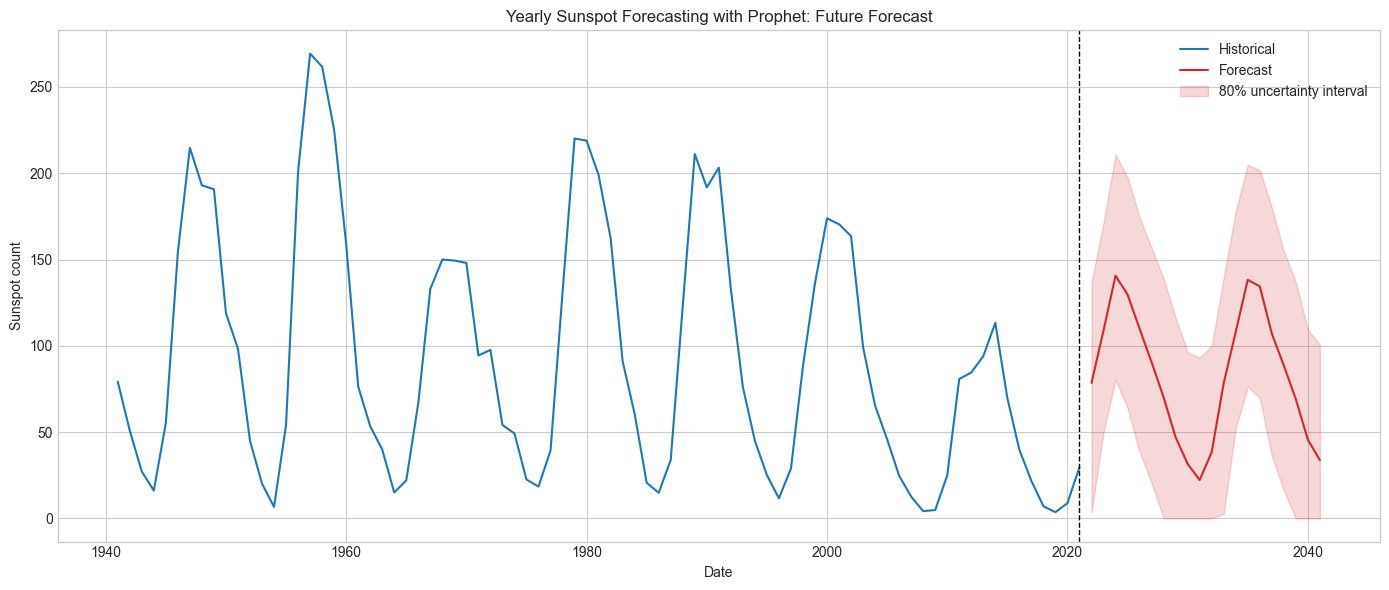

In [15]:
fig, ax = plt.subplots(figsize=(14, 6))
history_start = data["ds"].max() - pd.DateOffset(years=80)
recent_history = data[data["ds"] >= history_start]
future_forecast = forecast[forecast["ds"] > data["ds"].max()]

ax.plot(recent_history["ds"], recent_history["y"], label="Historical", color="#1f77b4")
ax.plot(future_forecast["ds"], future_forecast["yhat"], label="Forecast", color="#d62728")
ax.fill_between(
    future_forecast["ds"],
    future_forecast["yhat_lower"],
    future_forecast["yhat_upper"],
    color="#d62728",
    alpha=0.18,
    label="80% uncertainty interval",
)
ax.axvline(data["ds"].max(), color="black", linestyle="--", linewidth=1)
ax.set(title="Yearly Sunspot Forecasting with Prophet: Future Forecast", xlabel="Date", ylabel="Sunspot count")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Interpretation and limitations

- The model selection table reports genuinely out-of-sample performance over the most recent 22 years (two solar cycles).
- MAE is emphasized because zero sunspot counts make ordinary MAPE undefined. The displayed MAPE uses only nonzero actual observations.
- Prophet provides an interpretable trend-and-seasonality forecast, but solar activity is a complex physical process. Forecast uncertainty increases with the horizon, and these estimates should not be treated as operational space-weather predictions.
- The selected configuration is refitted on the complete observed history before producing the final yearly forecast.